In [1]:
# First thing we have to do is to convert whatsapp chat which is in text format to a pandas dataframe

In [2]:
import re
import pandas as pd

In [3]:
f = open(r'WhatsApp Chat with Engineering Physics 23 official.txt', encoding = 'utf-8')

In [4]:
data = f.read()

In [5]:
print(data)

9/25/23, 11:16 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*
9/25/23, 11:05 PM - Raj Sureka IIT Ropar created group "Engineering Physics 22 official"
9/25/23, 11:16 PM - You joined using a group link.
9/25/23, 11:40 PM - Siddharth Sinha IIT RPR joined using a group link.
9/25/23, 11:40 PM - Kabir IIT Ropar joined using a group link.
9/26/23, 12:01 AM - Siddharth Sinha IIT RPR added Ponnathavan IIT ROPAR
9/26/23, 12:50 AM - Raj Sureka IIT Ropar: Guys Add Everyone, because this is now official group of our branch!
9/26/23, 12:51 AM - Raj Sureka IIT Ropar: Here I will share all the updates/ announcement s n will conduct polls
9/26/23, 12:51 AM - Raj Sureka IIT Ropar changed the group name from "Engineering Physics 22 official" to "Engineering Physics 23 official"
9/26/23, 12:52 AM - Lavanya Lahane IIT Ropar added Aditya Deori IIT ROPAR, Arshpreet Singh IIT Ropar, Ashay Dwivedi IIT Ropar, Kavyam 245, Krishnav, Mi

In [6]:
print(type(data))

<class 'str'>


In [7]:
# Now we want to split the chat into date, sender name and actual message
# We will write a regular expression string to find 2 patterns in the chat: one for the sender name and actual message and another for the date and time 

In [8]:
split_pattern = r'\d{1,2}/\d{1,2}/\d{2},\s\d{1,2}:\d{2}\s?[AP]M\s-\s'
date_pattern  = r'\d{1,2}/\d{1,2}/\d{2},\s\d{1,2}:\d{2}\s?[AP]M'

In [9]:
# During analysis found some unicode esacpe characters, we have to replace those for better analysis
# data = data.replace('\u202f', ' ')
# data = data.replace('\u2069', '')
# data = data.replace('\u2068', '')
# data = data.replace('\n', '')

In [10]:
messages = re.split(split_pattern, data.replace('\u202f', ' '))[1:]
messages

['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n',
 'Raj Sureka IIT Ropar created group "Engineering Physics 22 official"\n',
 'You joined using a group link.\n',
 'Siddharth Sinha IIT RPR joined using a group link.\n',
 'Kabir IIT Ropar joined using a group link.\n',
 'Siddharth Sinha IIT RPR added Ponnathavan IIT ROPAR\n',
 'Raj Sureka IIT Ropar: Guys Add Everyone, because this is now official group of our branch!\n',
 'Raj Sureka IIT Ropar: Here I will share all the updates/ announcement s n will conduct polls\n',
 'Raj Sureka IIT Ropar changed the group name from "Engineering Physics 22 official" to "Engineering Physics 23 official"\n',
 'Lavanya Lahane IIT Ropar added Aditya Deori IIT ROPAR, Arshpreet Singh IIT Ropar, Ashay Dwivedi IIT Ropar, Kavyam 245, Krishnav, Mihika IIT RPR, Mohi Modi IIT Ropar, Pavan IIT Ropar, Rahul IIT Ropar, Triman Singh IIT Ropar, +91 94129 37033, and +91 99993 50941\n',
 'Lavanya 

In [11]:
dates = re.findall(date_pattern, data.replace('\u202f', ' '))
dates

['9/25/23, 11:16 PM',
 '9/25/23, 11:05 PM',
 '9/25/23, 11:16 PM',
 '9/25/23, 11:40 PM',
 '9/25/23, 11:40 PM',
 '9/26/23, 12:01 AM',
 '9/26/23, 12:50 AM',
 '9/26/23, 12:51 AM',
 '9/26/23, 12:51 AM',
 '9/26/23, 12:52 AM',
 '9/26/23, 12:52 AM',
 '9/26/23, 12:53 AM',
 '9/26/23, 5:22 PM',
 '9/26/23, 5:24 PM',
 '9/26/23, 5:25 PM',
 '9/27/23, 1:01 PM',
 '9/27/23, 1:01 PM',
 '9/27/23, 1:03 PM',
 '9/28/23, 2:47 PM',
 '9/28/23, 2:47 PM',
 '9/28/23, 2:48 PM',
 '9/28/23, 2:52 PM',
 '9/28/23, 2:52 PM',
 '9/28/23, 3:15 PM',
 '9/28/23, 7:51 PM',
 '9/28/23, 7:52 PM',
 '9/28/23, 7:52 PM',
 '9/28/23, 7:53 PM',
 '9/28/23, 7:53 PM',
 '9/28/23, 7:55 PM',
 '9/28/23, 7:55 PM',
 '9/28/23, 7:56 PM',
 '9/28/23, 8:07 PM',
 '9/28/23, 8:26 PM',
 '9/28/23, 8:53 PM',
 '9/28/23, 8:53 PM',
 '9/28/23, 8:53 PM',
 '9/28/23, 8:54 PM',
 '9/28/23, 8:54 PM',
 '9/28/23, 9:09 PM',
 '9/30/23, 1:11 PM',
 '9/30/23, 1:11 PM',
 '9/30/23, 1:11 PM',
 '9/30/23, 1:12 PM',
 '10/1/23, 6:58 PM',
 '10/3/23, 5:05 PM',
 '10/3/23, 5:29 PM',
 

In [12]:
df = pd.DataFrame({'user_messages': messages, 'date': dates})
df['user_messages'] = df['user_messages'].str.replace('\n', ' ').str.strip()
df['date'] = df['date'].str.replace(',' , '').str.strip()
df.head(10)

,user_messages,date
0,Messages and calls are end-to-end encrypted. O...,9/25/23 11:16 PM
1,"Raj Sureka IIT Ropar created group ""Engineerin...",9/25/23 11:05 PM
2,You joined using a group link.,9/25/23 11:16 PM
3,Siddharth Sinha IIT RPR joined using a group l...,9/25/23 11:40 PM
4,Kabir IIT Ropar joined using a group link.,9/25/23 11:40 PM
5,Siddharth Sinha IIT RPR added Ponnathavan IIT ...,9/26/23 12:01 AM
6,"Raj Sureka IIT Ropar: Guys Add Everyone, becau...",9/26/23 12:50 AM
7,Raj Sureka IIT Ropar: Here I will share all th...,9/26/23 12:51 AM
8,Raj Sureka IIT Ropar changed the group name fr...,9/26/23 12:51 AM
9,Lavanya Lahane IIT Ropar added Aditya Deori II...,9/26/23 12:52 AM


In [13]:
# Now we are dividing the user_messages into user and message

In [14]:
user = []
messages = []
for message in df['user_messages']:
    entry = re.split(r'([\w\W]+?):\s', message, maxsplit=1)
    if entry[1:]:
        user.append(entry[1])
        messages.append(entry[2])
    else:
        user.append('Group Notification')
        messages.append(entry[0])

df['user'] = user
df['message'] = messages

In [15]:
df = df.drop(columns = ['user_messages'])

In [16]:
df['date'] = df['date'].str.strip()

In [17]:
df['date'] = pd.to_datetime(df['date'], format = '%m/%d/%y %I:%M %p')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['time'] = df['date'].dt.strftime('%I:%M %p')

In [18]:
df = df[['date', 'user', 'message', 'year', 'month', 'month_num', 'day', 'time']]
df

,date,user,message,year,month,month_num,day,time
0,2023-09-25 23:16:00,Group Notification,Messages and calls are end-to-end encrypted. O...,2023,September,9,25,11:16 PM
1,2023-09-25 23:05:00,Group Notification,"Raj Sureka IIT Ropar created group ""Engineerin...",2023,September,9,25,11:05 PM
2,2023-09-25 23:16:00,Group Notification,You joined using a group link.,2023,September,9,25,11:16 PM
3,2023-09-25 23:40:00,Group Notification,Siddharth Sinha IIT RPR joined using a group l...,2023,September,9,25,11:40 PM
4,2023-09-25 23:40:00,Group Notification,Kabir IIT Ropar joined using a group link.,2023,September,9,25,11:40 PM
...,...,...,...,...,...,...,...,...
8930,2026-09-11 13:54:00,Kabir IIT Ropar,Bhar skte ho if u wanna,2026,September,9,11,01:54 PM
8931,2026-09-11 13:58:00,Lavanya Lahane IIT Ropar,Fine to ni lagega n?,2026,September,9,11,01:58 PM
8932,2026-09-11 14:02:00,Kabir IIT Ropar,Dekh fine ka chakkar h toh bhardi,2026,September,9,11,02:02 PM
8933,2026-09-11 14:02:00,Kabir IIT Ropar,Bhardo*,2026,September,9,11,02:02 PM


In [19]:
x = df['user'].value_counts().head()

In [20]:
import  matplotlib.pyplot as plt

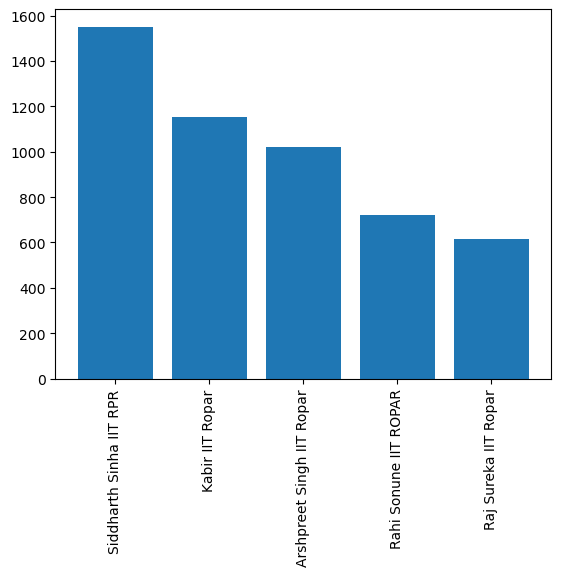

In [21]:
plt.bar(x.index, x.values)
plt.xticks(rotation = 'vertical')
plt.plot()
plt.show()

In [22]:
# Percent of total messges

In [23]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns = {'count':'percent'}).head()

,user,percent
0,Siddharth Sinha IIT RPR,17.36
1,Kabir IIT Ropar,12.93
2,Arshpreet Singh IIT Ropar,11.43
3,Rahi Sonune IIT ROPAR,8.08
4,Raj Sureka IIT Ropar,6.91


In [24]:
# Finding top 20 words

In [25]:
from collections import Counter

In [26]:
temp = df[df['user'] != 'Group Notification']

In [27]:
temp = temp[temp['message'] != '<Media omitted>']

In [28]:
file = open(r"C:\Users\suraj\OneDrive\Desktop\Projects\Whatsapp Chat Analysis\stop_hinglish.txt")
stop_words = file.read()
temp['message'] = temp['message'].str.replace('\u2069', '')
temp['message'] = temp['message'].str.replace('\u2068', '')

In [29]:
words = []
for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [30]:
Counter(words).most_common(20)

[('message', 543),
 ('iit', 400),
 ('ropar', 357),
 ('class', 292),
 ('deleted', 289),
 ('lab', 237),
 ('<this', 232),
 ('edited>', 232),
 ('option:', 177),
 ('quiz', 172),
 ('votes)', 163),
 ('singh', 130),
 ('mail', 129),
 ('course', 117),
 ('@arshpreet', 107),
 ('sem', 96),
 ('@rahi', 94),
 ('sonune', 93),
 ('classes', 88),
 ('today', 87)]

In [31]:
temp

,date,user,message,year,month,month_num,day,time
6,2023-09-26 00:50:00,Raj Sureka IIT Ropar,"Guys Add Everyone, because this is now officia...",2023,September,9,26,12:50 AM
7,2023-09-26 00:51:00,Raj Sureka IIT Ropar,Here I will share all the updates/ announcemen...,2023,September,9,26,12:51 AM
12,2023-09-26 17:22:00,Raj Sureka IIT Ropar,29 th schedule 1) viva is preponed to 27th 2...,2023,September,9,26,05:22 PM
13,2023-09-26 17:24:00,Raj Sureka IIT Ropar,So basically you will have no problem if you t...,2023,September,9,26,05:24 PM
14,2023-09-26 17:25:00,Raj Sureka IIT Ropar,*Important announcement* Tomorrow's class of G...,2023,September,9,26,05:25 PM
...,...,...,...,...,...,...,...,...
8930,2026-09-11 13:54:00,Kabir IIT Ropar,Bhar skte ho if u wanna,2026,September,9,11,01:54 PM
8931,2026-09-11 13:58:00,Lavanya Lahane IIT Ropar,Fine to ni lagega n?,2026,September,9,11,01:58 PM
8932,2026-09-11 14:02:00,Kabir IIT Ropar,Dekh fine ka chakkar h toh bhardi,2026,September,9,11,02:02 PM
8933,2026-09-11 14:02:00,Kabir IIT Ropar,Bhardo*,2026,September,9,11,02:02 PM


In [32]:
import emoji

In [33]:
# if selected_user != 'Overall':
#     df = df[df['user'] == selected_user]
emoji_list = []
for message in df['message']:
    for char in message:
        if emoji.is_emoji(char):
            emoji_list.append(char)
emoji_df = pd.DataFrame(Counter(emoji_list), columns = ['emoji', 'count'])
emoji_df = pd.DataFrame(Counter(emoji_list).most_common(), columns = ['emoji', 'count'])

In [34]:
emoji_df

,emoji,count
0,🤣,292
1,💀,255
2,😭,168
3,😂,113
4,🥳,94
...,...,...
142,🫃,1
143,😇,1
144,😓,1
145,⚰,1


In [35]:
df

,date,user,message,year,month,month_num,day,time
0,2023-09-25 23:16:00,Group Notification,Messages and calls are end-to-end encrypted. O...,2023,September,9,25,11:16 PM
1,2023-09-25 23:05:00,Group Notification,"Raj Sureka IIT Ropar created group ""Engineerin...",2023,September,9,25,11:05 PM
2,2023-09-25 23:16:00,Group Notification,You joined using a group link.,2023,September,9,25,11:16 PM
3,2023-09-25 23:40:00,Group Notification,Siddharth Sinha IIT RPR joined using a group l...,2023,September,9,25,11:40 PM
4,2023-09-25 23:40:00,Group Notification,Kabir IIT Ropar joined using a group link.,2023,September,9,25,11:40 PM
...,...,...,...,...,...,...,...,...
8930,2026-09-11 13:54:00,Kabir IIT Ropar,Bhar skte ho if u wanna,2026,September,9,11,01:54 PM
8931,2026-09-11 13:58:00,Lavanya Lahane IIT Ropar,Fine to ni lagega n?,2026,September,9,11,01:58 PM
8932,2026-09-11 14:02:00,Kabir IIT Ropar,Dekh fine ka chakkar h toh bhardi,2026,September,9,11,02:02 PM
8933,2026-09-11 14:02:00,Kabir IIT Ropar,Bhardo*,2026,September,9,11,02:02 PM


In [36]:
message_timeline = pd.DataFrame(df.groupby(['year', 'month_num', 'month']).count()['message']).reset_index().sort_values(by = ['year', 'month_num'])

In [37]:
message_timeline

,year,month_num,month,message
0,2023,9,September,44
1,2023,10,October,138
2,2023,11,November,318
3,2023,12,December,248
4,2024,1,January,103
5,2024,2,February,161
6,2024,3,March,156
7,2024,4,April,97
8,2024,5,May,304
9,2024,6,June,3


In [38]:
timeline = []
for i in range (message_timeline.shape[0]):
    timeline.append(message_timeline['month'][i] + '-' + str(message_timeline['year'][i]))
timeline

['September-2023',
 'October-2023',
 'November-2023',
 'December-2023',
 'January-2024',
 'February-2024',
 'March-2024',
 'April-2024',
 'May-2024',
 'June-2024',
 'July-2024',
 'August-2024',
 'September-2024',
 'October-2024',
 'November-2024',
 'December-2024',
 'January-2025',
 'February-2025',
 'March-2025',
 'April-2025',
 'May-2025',
 'June-2025',
 'July-2025',
 'August-2025',
 'September-2025',
 'October-2025',
 'November-2025',
 'December-2025',
 'January-2026',
 'February-2026',
 'March-2026',
 'April-2026',
 'May-2026',
 'June-2026',
 'July-2026',
 'August-2026',
 'September-2026']

In [39]:
message_timeline['timeline'] = timeline

In [40]:
message_timeline

,year,month_num,month,message,timeline
0,2023,9,September,44,September-2023
1,2023,10,October,138,October-2023
2,2023,11,November,318,November-2023
3,2023,12,December,248,December-2023
4,2024,1,January,103,January-2024
5,2024,2,February,161,February-2024
6,2024,3,March,156,March-2024
7,2024,4,April,97,April-2024
8,2024,5,May,304,May-2024
9,2024,6,June,3,June-2024


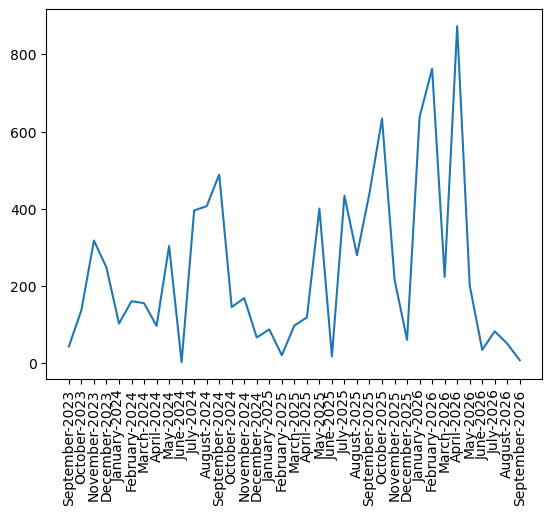

In [41]:
plt.plot(message_timeline['timeline'], message_timeline['message'])
plt.xticks(rotation = 'vertical')
plt.show()

In [50]:
df['day_name'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df

,date,user,message,year,month,month_num,day,time,day_name,hour
0,2023-09-25 23:16:00,Group Notification,Messages and calls are end-to-end encrypted. O...,2023,September,9,25,11:16 PM,Monday,23
1,2023-09-25 23:05:00,Group Notification,"Raj Sureka IIT Ropar created group ""Engineerin...",2023,September,9,25,11:05 PM,Monday,23
2,2023-09-25 23:16:00,Group Notification,You joined using a group link.,2023,September,9,25,11:16 PM,Monday,23
3,2023-09-25 23:40:00,Group Notification,Siddharth Sinha IIT RPR joined using a group l...,2023,September,9,25,11:40 PM,Monday,23
4,2023-09-25 23:40:00,Group Notification,Kabir IIT Ropar joined using a group link.,2023,September,9,25,11:40 PM,Monday,23
...,...,...,...,...,...,...,...,...,...,...
8930,2026-09-11 13:54:00,Kabir IIT Ropar,Bhar skte ho if u wanna,2026,September,9,11,01:54 PM,Friday,13
8931,2026-09-11 13:58:00,Lavanya Lahane IIT Ropar,Fine to ni lagega n?,2026,September,9,11,01:58 PM,Friday,13
8932,2026-09-11 14:02:00,Kabir IIT Ropar,Dekh fine ka chakkar h toh bhardi,2026,September,9,11,02:02 PM,Friday,14
8933,2026-09-11 14:02:00,Kabir IIT Ropar,Bhardo*,2026,September,9,11,02:02 PM,Friday,14


In [51]:
pd.DataFrame(df['day_name'].value_counts()).reset_index()

,day_name,count
0,Wednesday,1863
1,Thursday,1644
2,Friday,1466
3,Tuesday,1457
4,Monday,1080
5,Saturday,802
6,Sunday,623


In [52]:
# Calculating period

In [54]:
period = []
for hour in df['hour']:
    if hour == 23:
        period.append(str(hour) + '-' + str('00'))
    elif hour == 0:
        period.append(str('00') + '-' + str(hour + 1))
    else:
        period.append(str(hour) + '-' + str(hour + 1))
df['period'] = period
df

,date,user,message,year,month,month_num,day,time,day_name,hour,period
0,2023-09-25 23:16:00,Group Notification,Messages and calls are end-to-end encrypted. O...,2023,September,9,25,11:16 PM,Monday,23,23-00
1,2023-09-25 23:05:00,Group Notification,"Raj Sureka IIT Ropar created group ""Engineerin...",2023,September,9,25,11:05 PM,Monday,23,23-00
2,2023-09-25 23:16:00,Group Notification,You joined using a group link.,2023,September,9,25,11:16 PM,Monday,23,23-00
3,2023-09-25 23:40:00,Group Notification,Siddharth Sinha IIT RPR joined using a group l...,2023,September,9,25,11:40 PM,Monday,23,23-00
4,2023-09-25 23:40:00,Group Notification,Kabir IIT Ropar joined using a group link.,2023,September,9,25,11:40 PM,Monday,23,23-00
...,...,...,...,...,...,...,...,...,...,...,...
8930,2026-09-11 13:54:00,Kabir IIT Ropar,Bhar skte ho if u wanna,2026,September,9,11,01:54 PM,Friday,13,13-14
8931,2026-09-11 13:58:00,Lavanya Lahane IIT Ropar,Fine to ni lagega n?,2026,September,9,11,01:58 PM,Friday,13,13-14
8932,2026-09-11 14:02:00,Kabir IIT Ropar,Dekh fine ka chakkar h toh bhardi,2026,September,9,11,02:02 PM,Friday,14,14-15
8933,2026-09-11 14:02:00,Kabir IIT Ropar,Bhardo*,2026,September,9,11,02:02 PM,Friday,14,14-15


In [55]:
# Now plot the heatmap

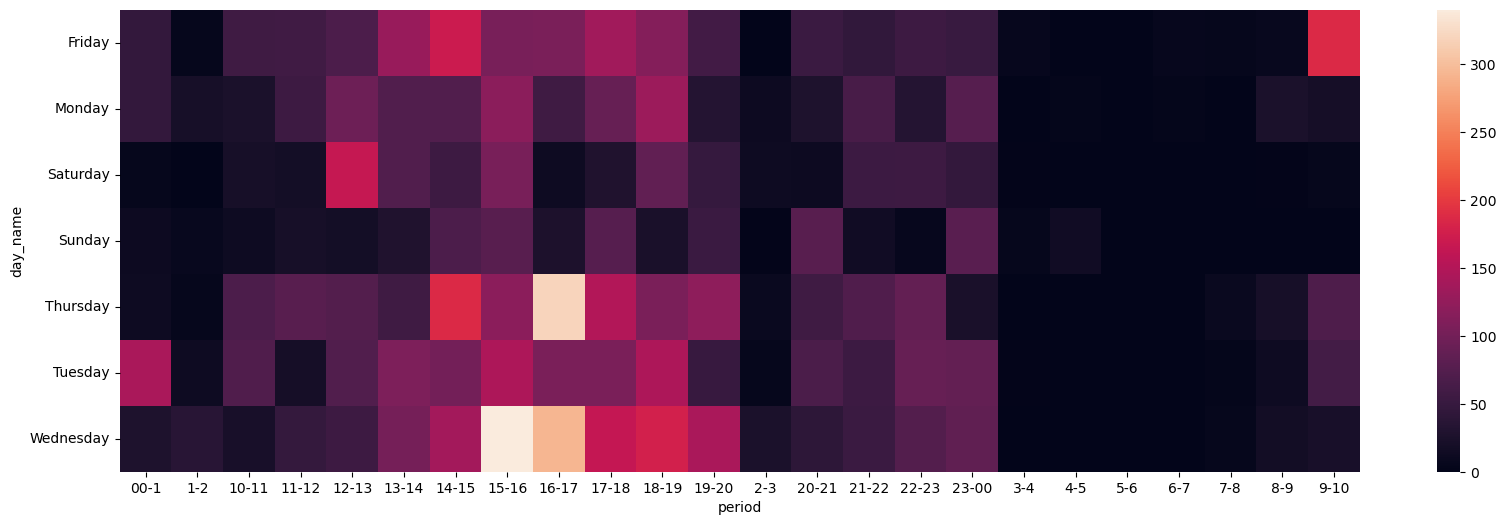

In [56]:
import seaborn as sns
plt.figure(figsize = (20, 6))
sns.heatmap(df.pivot_table(index = 'day_name', columns = 'period', values = 'message', aggfunc = 'count').fillna(0))
plt.yticks(rotation = 'horizontal')
plt.show()